In [9]:
import tensorflow as tf

In [10]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [11]:
x_train, x_test = x_train/255.0, x_test/255.0

In [12]:
x_train.shape

(60000, 28, 28)

In [13]:
x_test.shape

(10000, 28, 28)

In [17]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


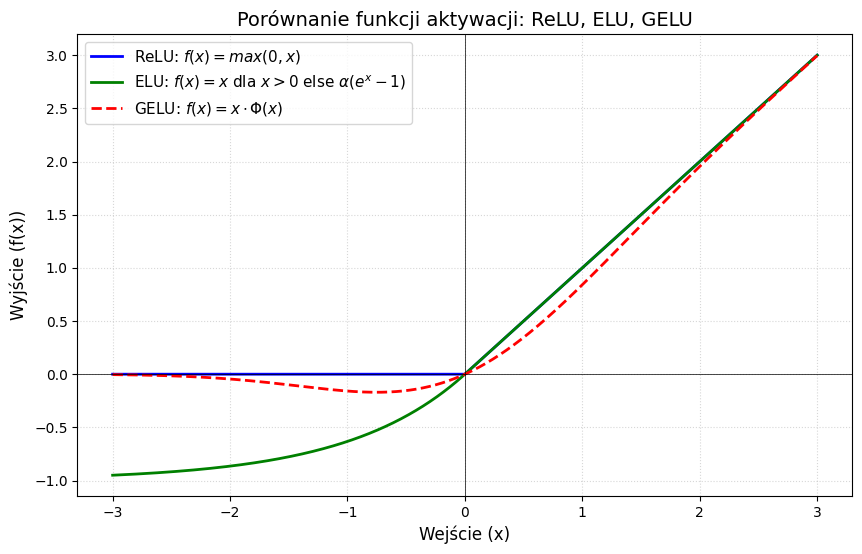


--- OPIS I ZASTOSOWANIE FUNKCJI AKTYWACJI ---

1. ReLU (Rectified Linear Unit)
   - Wzór: f(x) = max(0, x)
   - Opis: Najpopularniejsza funkcja aktywacji w głębokich sieciach neuronowych. 
     Jest niezwykle szybka w obliczeniach i pomaga redukować problem zanikającego gradientu (vanishing gradient).
   - Zastosowanie: Standardowy wybór w ukrytych warstwach sieci wielowarstwowych (MLP) oraz konwolucyjnych (CNN).

2. ELU (Exponential Linear Unit)
   - Wzór: f(x) = x dla x > 0 oraz alpha * (exp(x) - 1) dla x <= 0
   - Opis: W przeciwieństwie do ReLU, ELU pozwala na uzyskanie ujemnych wartości wyjściowych, co zbliża 
     średnią aktywację warstwy do zera i przyspiesza proces uczenia. Jest odporna na problem "martwych" neuronów.
   - Zastosowanie: Głębokie sieci neuronowe, w których zależy nam na szybszej zbieżności i lepszej stabilności niż przy ReLU.

3. GELU (Gaussian Error Linear Unit)
   - Wzór: f(x) = x * P(X <= x) = x * Phi(x), gdzie Phi(x) to dystrybuanta standardowego rozkładu 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

# Definicje funkcji aktywacji
def relu(x):
    return np.maximum(0, x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def gelu(x):
    # Dokładna definicja GELU oparta na dystrybuancie rozkładu normalnego
    return x * 0.5 * (1.0 + scipy.special.erf(x / np.sqrt(2.0)))

# Przygotowanie danych do wykresu
x = np.linspace(-3, 3, 1000)
y_relu = relu(x)
y_elu = elu(x)
y_gelu = gelu(x)

# Tworzenie wykresu
plt.figure(figsize=(10, 6))
plt.plot(x, y_relu, label=r'ReLU: $f(x) = 	{max}(0, x)$', color='blue', linewidth=2)
plt.plot(x, y_elu, label=r'ELU: $f(x) = x$ dla $x > 0$ else $\alpha(e^x - 1)$', color='green', linewidth=2)
plt.plot(x, y_gelu, label=r'GELU: $f(x) = x \cdot \Phi(x)$', color='red', linewidth=2, linestyle='--')

plt.title('Porównanie funkcji aktywacji: ReLU, ELU, GELU', fontsize=14)
plt.xlabel('Wejście (x)', fontsize=12)
plt.ylabel('Wyjście (f(x))', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.legend(fontsize=11)
plt.show()

# Opis zastosowań
print("""
--- OPIS I ZASTOSOWANIE FUNKCJI AKTYWACJI ---

1. ReLU (Rectified Linear Unit)
   - Wzór: f(x) = max(0, x)
   - Opis: Najpopularniejsza funkcja aktywacji w głębokich sieciach neuronowych.
     Jest niezwykle szybka w obliczeniach i pomaga redukować problem zanikającego gradientu (vanishing gradient).
   - Zastosowanie: Standardowy wybór w ukrytych warstwach sieci wielowarstwowych (MLP) oraz konwolucyjnych (CNN).

2. ELU (Exponential Linear Unit)
   - Wzór: f(x) = x dla x > 0 oraz alpha * (exp(x) - 1) dla x <= 0
   - Opis: W przeciwieństwie do ReLU, ELU pozwala na uzyskanie ujemnych wartości wyjściowych, co zbliża
     średnią aktywację warstwy do zera i przyspiesza proces uczenia. Jest odporna na problem "martwych" neuronów.
   - Zastosowanie: Głębokie sieci neuronowe, w których zależy nam na szybszej zbieżności i lepszej stabilności niż przy ReLU.

3. GELU (Gaussian Error Linear Unit)
   - Wzór: f(x) = x * P(X <= x) = x * Phi(x), gdzie Phi(x) to dystrybuanta standardowego rozkładu normalnego.
   - Opis: Skaluje wejście przez prawdopodobieństwo tego, że losowa wartość jest mniejsza od niego.
     Zapewnia gładką (różniczkowalną w każdym punkcie) krzywiznę dla ujemnych wartości.
   - Zastosowanie: Standard w nowoczesnych architekturach przetwarzania języka naturalnego (NLP) takich jak BERT, GPT oraz modelach typu Vision Transformer (ViT).
""")

In [18]:
#propagacja wsteczna
model.compile(optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])

In [19]:
model.fit(x_train, y_train, epochs=25)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9147 - loss: 0.2941
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9575 - loss: 0.1434
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9668 - loss: 0.1080
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9725 - loss: 0.0868
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9770 - loss: 0.0753
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9797 - loss: 0.0643
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9823 - loss: 0.0567
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9827 - loss: 0.0512
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9841 - loss: 0.0474
Epoch 10/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9850 - loss: 0.0449
Epoch 11/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0416
Epoch 12/25
1875/1875 ━━━━━━━━

In [20]:
#ocena modelu
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9805 - loss: 0.0880

Test accuracy: 0.9804999828338623
